<a href="https://colab.research.google.com/github/Nihcas001/data_analysis_using_Python/blob/main/08(A)_Stock_Market_Analysis/Stock_analysis_using_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is Matplotlib?**

> Matplotlib is a Python library used to create graphs and visualizations from data.

For this problem, we will use Matplotlib to create:

* Line plot → Study share-price trends over time.
* Scatter plot → Study the relationship between variables.
* Histogram → Study the distribution of share prices.

The basic import is:

`import matplotlib.pyplot as plt`

Here:

* matplotlib → visualization library
* pyplot → module used for creating plots
* plt → short alias commonly used for pyplot

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV dataset
df = pd.read_csv("stock_market_prices.csv")

# Display first five records
df.head()

,Date,Company,Open,High,Low,Close,Volume
0,2025-01-01,TechNova,149.88,152.25,148.05,151.46,104886
1,2025-01-02,TechNova,151.35,153.78,148.50,149.08,241335
2,2025-01-03,TechNova,148.61,149.29,146.55,147.64,471909
3,2025-01-06,TechNova,148.18,148.48,141.09,141.28,478989
4,2025-01-07,TechNova,140.07,142.18,139.95,141.56,53890


**Understand the Dataset**

Before plotting, check the basic structure.

In [3]:
# Display number of rows and columns
print(df.shape)

# Display column names and data types
print(df.info())

# Display basic statistical information
print(df.describe())

(360, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     360 non-null    object 
 1   Company  360 non-null    object 
 2   Open     360 non-null    float64
 3   High     360 non-null    float64
 4   Low      360 non-null    float64
 5   Close    360 non-null    float64
 6   Volume   360 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 19.8+ KB
None
             Open        High         Low       Close         Volume
count  360.000000  360.000000  360.000000  360.000000     360.000000
mean   124.429861  126.159222  122.624778  124.344722  275419.816667
std     24.989868   25.292484   24.630466   24.915007  132099.817501
min     83.170000   84.070000   81.380000   83.150000   52050.000000
25%     98.372500  100.092500   96.640000   98.705000  161685.500000
50%    128.930000  131.040000  127.330000  128.860000  266746.5

**Convert Date into Date Format**

In [4]:
# Convert Date column from text to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check the data type
print(df["Date"].dtype)

datetime64[ns]


**Why Do We Need Visualization?**

Suppose the analyst wants to answer:

> "How has the share price of TechNova changed over time?"

Looking at 120 rows manually would be difficult.

### **Line Plot**

**What is a Line Plot?**

A line plot connects data points using lines.

It is especially useful for:

* Time-series data
* Stock prices
* Temperature
* Sales over time
* Population growth

For stock-market analysis:

```
Date → X-axis
Closing Price → Y-axis
```

**Basic Line Plot**

Let's plot TechNova's closing price.

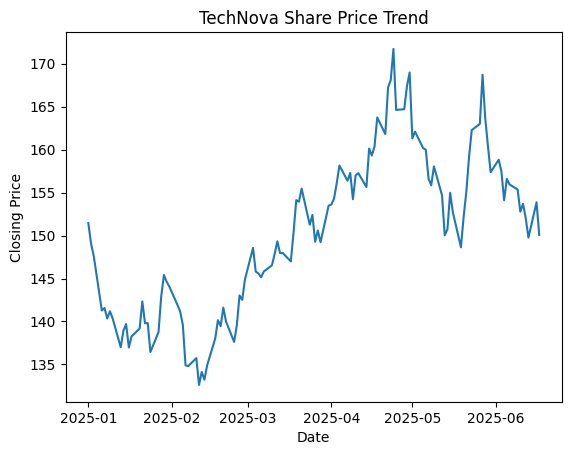

In [5]:
# Select data for TechNova
tech = df[df["Company"] == "TechNova"]

# Create a line plot
plt.plot(tech["Date"], tech["Close"])

# Add title and axis labels
plt.title("TechNova Share Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Display the plot
plt.show()

**Important concept**

This line:

`plt.plot(tech["Date"], tech["Close"])`

means:

```
X-axis → Date
Y-axis → Closing Price
```
So Matplotlib connects each day's closing price to the next day's closing price.

**Improve the Line Plot**

We can make the graph easier to understand.

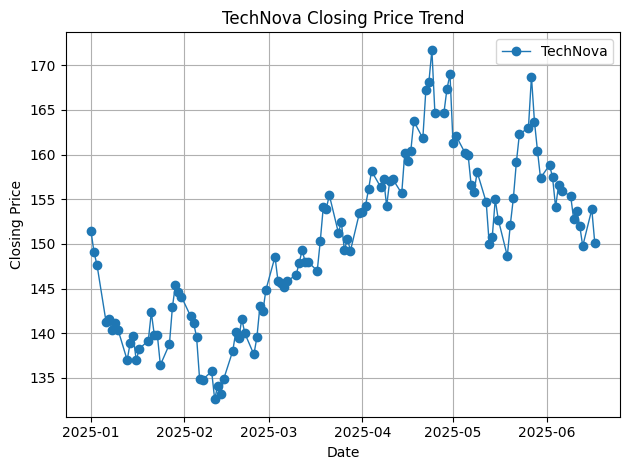

In [6]:
# Select TechNova data
tech = df[df["Company"] == "TechNova"]

# Create the line plot
plt.plot(
    tech["Date"],
    tech["Close"],
    marker="o",
    linewidth=1,
    label="TechNova"
)

# Add title and labels
plt.title("TechNova Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Display grid
plt.grid(True)

# Display legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

**New concepts**

`marker="o"`
→ Displays a small circle at each observation.

`linewidth=1`
→ Controls line thickness.

`label="TechNova"`
→ Gives a name to the plotted data.

`plt.legend()`
→ Displays the label.

`plt.grid(True)`
→ Displays grid lines.

`plt.tight_layout()`
→ Prevents labels from getting cut off.

**Compare Multiple Companies**

This is particularly useful for a stock-market analyst.

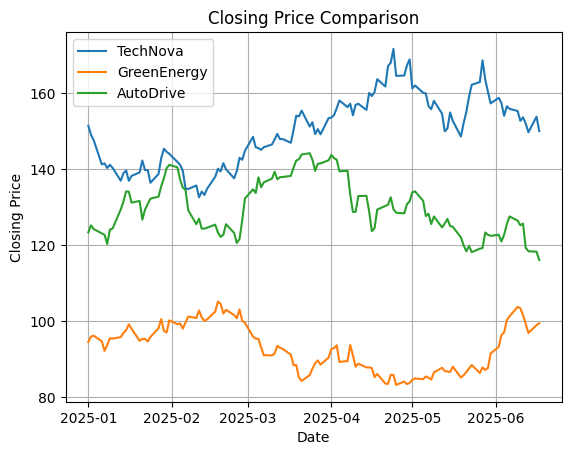

In [7]:
# Create a line plot for each company
for company in df["Company"].unique():

    # Select company-specific data
    company_data = df[df["Company"] == company]

    # Plot closing prices
    plt.plot(
        company_data["Date"],
        company_data["Close"],
        label=company
    )

# Add chart information
plt.title("Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Add grid and legend
plt.grid(True)
plt.legend()

# Display the plot
plt.show()

### **Scatter Plot**

**What is a Scatter Plot?**

A scatter plot represents individual observations as points.

It is mainly used to investigate the relationship between two numerical variables.

For example:

> Does trading volume have any relationship with closing price?

We can plot:
```
X-axis → Volume
Y-axis → Closing Price
```

**Basic Scatter Plot**

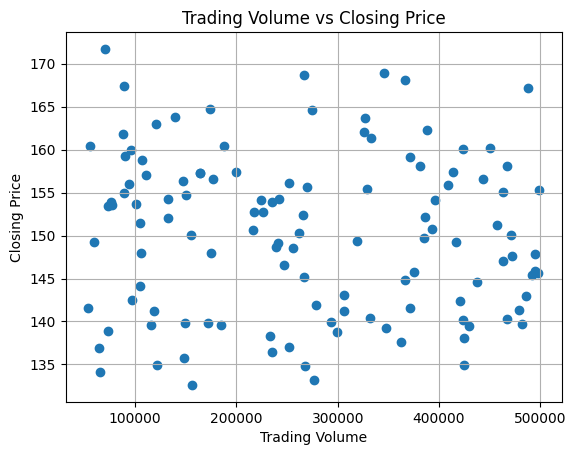

In [8]:
# Select TechNova data
tech = df[df["Company"] == "TechNova"]

# Create scatter plot
plt.scatter(
    tech["Volume"],
    tech["Close"]
)

# Add title and labels
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

# Display grid
plt.grid(True)

# Show plot
plt.show()

Each dot represents one trading day.

**Scatter Plot with Multiple Companies**

We can compare all companies.

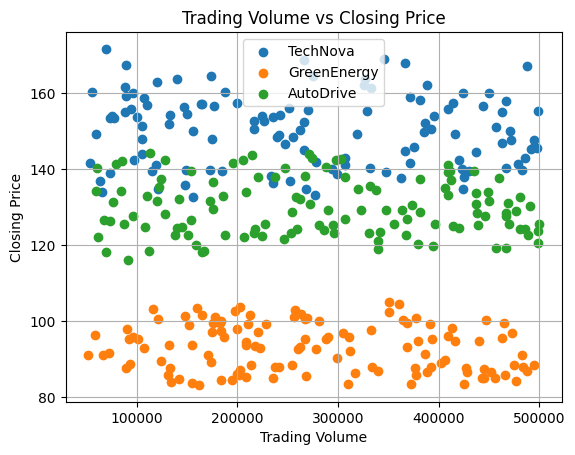

In [10]:
# Plot each company's observations
for company in df["Company"].unique():

    # Select company data
    company_data = df[df["Company"] == company]

    # Create scatter plot
    plt.scatter(
        company_data["Volume"],
        company_data["Close"],
        label=company
    )

# Add chart information
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

# Add legend and grid
plt.legend()
plt.grid(True)

# Display plot
plt.show()

**Interpretation**

The analyst can look for patterns such as:

* Points moving upward → possible positive relationship
* Points moving downward → possible negative relationship
* Randomly scattered points → weak relationship

> Important: A scatter plot can show association, but it does not automatically prove causation.

### **Histogram**
**What is a Histogram?**

A histogram shows the distribution of numerical data.

For example:

> What range of closing prices occurs most frequently?

We can use a histogram to answer this.

Unlike a line plot, a histogram groups numerical values into intervals called bins.

**Basic Histogram**

Let's create a histogram of TechNova's closing prices.

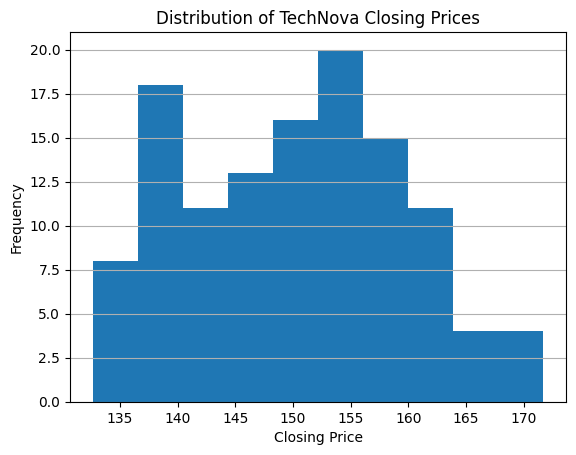

In [15]:
# Select TechNova data
tech = df[df["Company"] == "TechNova"]

# Create histogram
plt.hist(
    tech["Close"],
    bins=10
)

# Add title and labels
plt.title("Distribution of TechNova Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

# Add grid
plt.grid(axis="y")

# Display plot
plt.show()

**Understanding bins**

One important concept in a histogram is: `bins=10`

> It means that Matplotlib divides the range of closing prices into 10 intervals.

For example:
```
Price Range       Frequency
130–135              8
135–140             15
140–145             22
145–150             28
150–155             20
...
```
If we use `bins=5`. We get fewer and wider groups.

If we use `bins=20`. We get more and narrower groups.

> So the number of bins affects how detailed the distribution looks.

**Histogram for All Companies**

We can also examine the closing-price distribution of all companies.

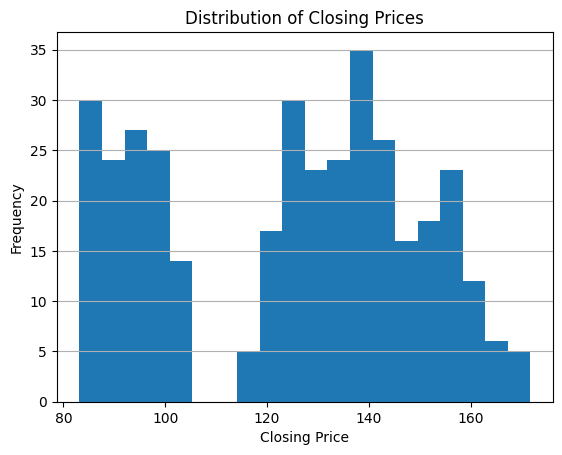

In [16]:
# Create histogram using all closing prices
plt.hist(
    df["Close"],
    bins=20
)

# Add title and labels
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

# Add grid
plt.grid(axis="y")

# Display plot
plt.show()

**Add Transparency to Histogram**

If we want to compare two companies:

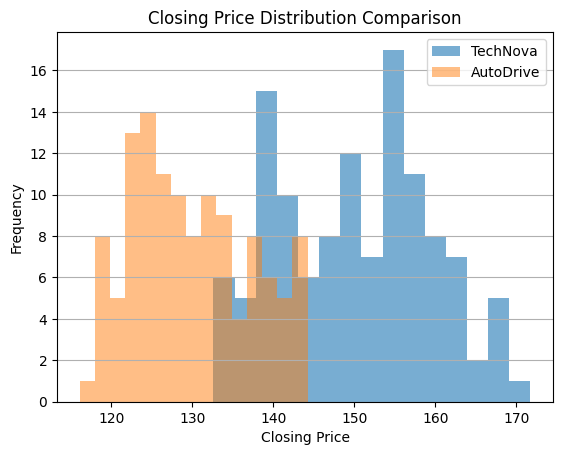

In [21]:
# Select company data
tech = df[df["Company"] == "TechNova"]
auto = df[df["Company"] == "AutoDrive"]

# Plot both distributions
plt.hist(
    tech["Close"],
    bins=15,
    alpha=0.6,
    label="TechNova"
)

plt.hist(
    auto["Close"],
    bins=15,
    alpha=0.5,
    label="AutoDrive"
)

# Add chart information
plt.title("Closing Price Distribution Comparison")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

# Add legend and grid
plt.legend()
plt.grid(axis="y")

# Display plot
plt.show()

Here: `alpha=0.6`

controls the transparency of the histogram.

This makes overlapping distributions easier to see.

**Complete Program**

Once students understand each concept separately, they can combine everything into one program.

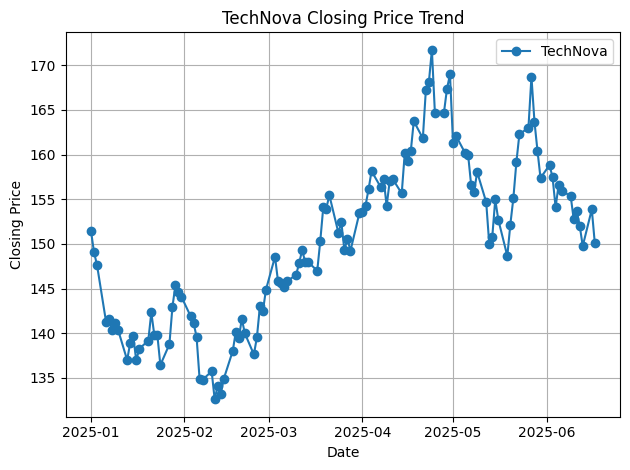

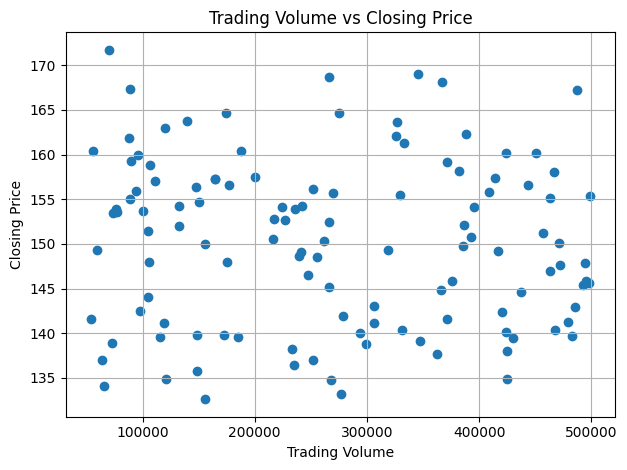

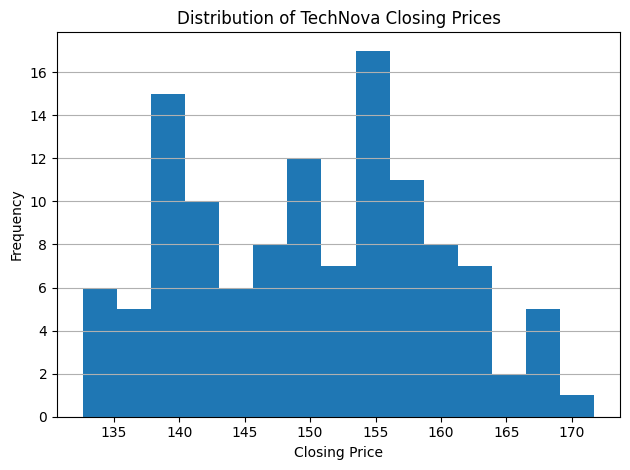

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load stock-market dataset
df = pd.read_csv("stock_market_prices.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])


# =====================================================
# 1. LINE PLOT
# =====================================================

# Select TechNova data
tech = df[df["Company"] == "TechNova"]

# Plot closing price over time
plt.plot(
    tech["Date"],
    tech["Close"],
    marker="o",
    label="TechNova"
)

# Add title and labels
plt.title("TechNova Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Add grid and legend
plt.grid(True)
plt.legend()

# Improve layout and display
plt.tight_layout()
plt.show()


# =====================================================
# 2. SCATTER PLOT
# =====================================================

# Plot trading volume against closing price
plt.scatter(
    tech["Volume"],
    tech["Close"]
)

# Add title and labels
plt.title("Trading Volume vs Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

# Add grid
plt.grid(True)

# Display plot
plt.tight_layout()
plt.show()


# =====================================================
# 3. HISTOGRAM
# =====================================================

# Plot distribution of closing prices
plt.hist(
    tech["Close"],
    bins=15
)

# Add title and labels
plt.title("Distribution of TechNova Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

# Add grid
plt.grid(axis="y")

# Display plot
plt.tight_layout()
plt.show()